# Transfer of models between cameras

Calibration transfer is essential when we need to apply a model developed on one instrument (primary) to data collected on another instrument (secondary). Due to instrumental differences, direct application often fails. We use standardization methods to bridge this gap:
- **Direct Standardization (DS)**: Creates a linear transformation F such that X_secondary = X_primary * F
- **Piecewise Direct Standardization (PDS)**: Similar to DS but uses local windows for transformation

The goal is to transform secondary instrument data to look like primary instrument data, allowing the original calibration model to work effectively.


In [59]:
import numpy as np
import pandas as pd
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import pandas as pd
import pycaltransfer.caltransfer as caltransfer

## Loading and Preparing the Data

We use a public dataset of NIR spectra from pharmaceutical tablets. The same tablets were measured on two instruments.

We:
- Load the dataset
- Remove a few known problematic samples (based on literature)
- Separate calibration and test sets for both instruments

In [60]:
data_url = "https://gitlab.com/vfonsecad/chemometrics_data/-/raw/main/data/nir_pharmaceutical_tablets/nir_shootout_2002_all.csv"
data_pd_raw = pd.read_csv(data_url, sep = ";", index_col = 0)
data_pd_all = data_pd_raw.dropna(axis=0, how='any') # dropping na for this analysis
print(data_pd_all)
print(data_pd_all.columns)

           sample_id         type    instrument    weight     hardness  \
0       sample_cal_0  calibration  instrument_1  378.019989  20.900000   
1       sample_cal_1  calibration  instrument_1  377.940002  18.100000   
2       sample_cal_2  calibration  instrument_1  377.290009  19.200001   
3       sample_cal_3  calibration  instrument_1  380.929993  17.600000   
4       sample_cal_4  calibration  instrument_1  382.549988  20.200001   
..               ...          ...           ...         ...        ...   
455  sample_test_455         test  instrument_2  380.070007  18.299999   
456  sample_test_456         test  instrument_2  371.989990  17.900000   
457  sample_test_457         test  instrument_2  373.670013  20.000000   
458  sample_test_458         test  instrument_2  377.940002  18.500000   
459  sample_test_459         test  instrument_2  380.410004  16.799999   

       assay            1         2         3         4  ...       641  \
0    200.100006  3.222009  3.220346  

In [61]:
# drop samples according to ref paper https://doi.org/10.1016/j.saa.2019.117653

cal_samples = ["sample_cal_{}".format(ii-1) for ii in [19, 122, 126, 127]]
test_samples = ["sample_test_{}".format(ii-1) for ii in [11, 145, 267, 295, 294, 342, 313, 341, 343]]

data_pd = data_pd_all[~data_pd_all["sample_id"].isin(cal_samples + test_samples)]

## Selecting Transfer Samples

To learn how the two instruments differ, we need **transfer samples** – the same tablets measured on both instruments.

These are used to calculate the transformation needed for transfer.

We randomly select 15 such samples and make sure they match correctly.

In [62]:
y_name = 'assay   ' # name of y variable

primary_name = "instrument_1" # Primary instrument (where original model was built)
secondary_name = "instrument_2"  #Secondary instrument (where we want to apply the model)

n_transfer = 15  # Number of samples measured on both instruments for transfer

In [63]:
# Extract calibration data from primary instrument
x_primary_cal_raw = np.array(data_pd[(data_pd["instrument"]==primary_name) & (data_pd["type"]=="calibration")].iloc[:,6:])
y_primary_cal = np.array(data_pd[(data_pd["instrument"]==primary_name) & (data_pd["type"]=="calibration")].loc[:,y_name])

# Extract test data from secondary instrument (this is what we want to predict)
x_secondary_test_raw = np.array(data_pd[(data_pd["instrument"]==secondary_name) & (data_pd["type"]=="test")].iloc[:,6:])
y_secondary_test = np.array(data_pd[(data_pd["instrument"]==secondary_name) & (data_pd["type"]=="test")].loc[:,y_name])

In [64]:
# Create transfer set: samples measured on both instruments
# This is crucial for calibration transfer - we need the same samples on both instruments
n_cal = x_primary_cal_raw.shape[0]

transfer_samples = np.random.choice(n_cal, n_transfer, replace = False)

df_transfer_primary = data_pd[(data_pd["instrument"]==primary_name) & (data_pd["type"]=="calibration")].iloc[transfer_samples]
df_transfer_primary_sorted = df_transfer_primary.sort_values("sample_id")
df_transfer_secondary_all = data_pd[(data_pd["instrument"]==secondary_name) & (data_pd["type"]=="calibration")]
df_transfer_secondary = df_transfer_secondary_all[df_transfer_secondary_all["sample_id"].isin(df_transfer_primary_sorted["sample_id"])]
df_transfer_secondary_sorted = df_transfer_secondary.sort_values("sample_id")

# Verify we have matching samples
print(np.all(df_transfer_primary_sorted["sample_id"] == df_transfer_secondary_sorted["sample_id"]))

x_primary_raw = np.array(df_transfer_primary_sorted.iloc[:,6:])
x_secondary_raw = np.array(df_transfer_secondary_sorted.iloc[:,6:])

y_primary = np.array(df_transfer_primary_sorted.loc[:,y_name]) # or None
y_secondary = np.array(df_transfer_secondary_sorted.loc[:,y_name]) # or None
# Define wavelength range
wv_range = np.arange(600, 1900,2)

K = wv_range.shape[0]

True


## Visualizing Instrument Differences

We plot the spectra of the same samples measured on both instruments.

If everything was ideal, the plots would overlap. But in reality, we see clear shifts between the primary and secondary instruments.

This shows why calibration transfer is necessary.

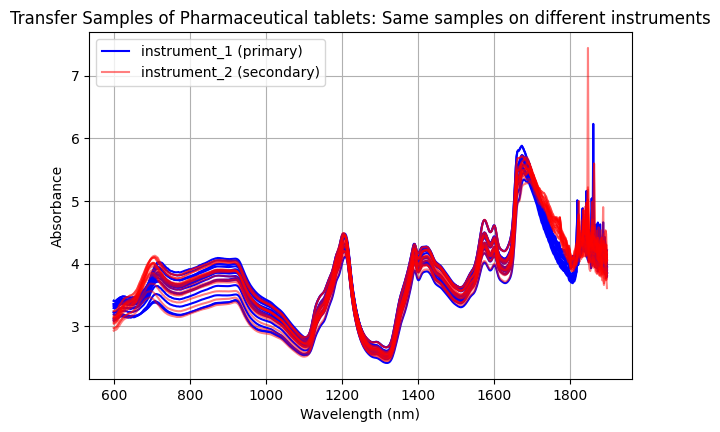

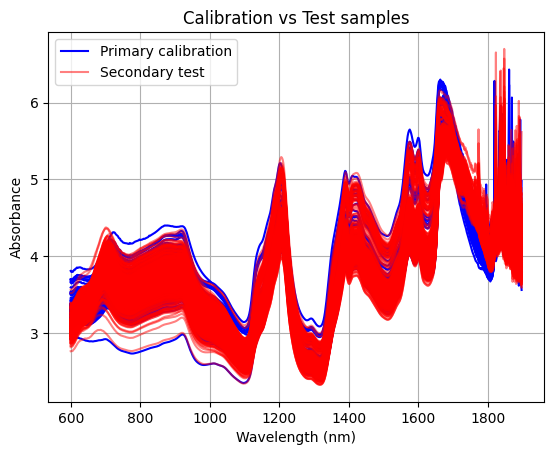

In [65]:
# Visualize instrumental differences
plt.subplots(figsize=(7,4.5))
plt.plot(wv_range,x_primary_raw[0], c = "blue", label = primary_name + " (primary)")
plt.plot(wv_range,x_primary_raw.T, c = "blue")
plt.plot(wv_range,x_secondary_raw[0], c = "red", alpha = 0.5, label = secondary_name + " (secondary)")
plt.plot(wv_range,x_secondary_raw.T, c = "red", alpha = 0.5)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Transfer Samples of Pharmaceutical tablets: Same samples on different instruments")
plt.legend(loc = 0)
plt.grid()
plt.show()


plt.plot(wv_range,x_primary_cal_raw[0], c = "blue", label = "Primary calibration")
plt.plot(wv_range,x_primary_cal_raw.T, c = "blue")
plt.plot(wv_range,x_secondary_test_raw[0], c = "red", alpha = 0.5, label = "Secondary test")
plt.plot(wv_range,x_secondary_test_raw.T, c = "red", alpha = 0.5)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Calibration vs Test samples")
plt.legend(loc = 0)
plt.grid()
plt.show()

## Original PLS Model on Primary Instrument

We fit a PLS model on the calibration data from the primary instrument using 5 components.

We extract:
- The X loadings (used to project new data)
- The regression vector B (used to predict Y)
- The intercept

This is our original model, which we'll try to reuse after transfer.

In [66]:
mod_lv = 5
x_primary_cal = x_primary_cal_raw.copy()
x_mean = np.mean(x_primary_cal,axis=0)

pls = PLSRegression(n_components = mod_lv,scale=False)
pls.fit(x_primary_cal, y_primary_cal)
T_scores = (x_primary_cal-x_mean).dot(pls.x_rotations_)
pls_ls = LinearRegression()
pls_ls.fit(T_scores,y_primary_cal) # output values need to be 1D always here

# deliver parameters for plsr
R = pls.x_rotations_ #loadings to calculate scores
q = pls_ls.coef_ # Y-regression coefficients
y_mean = pls_ls.intercept_ # Y-intercept
B = pls.coef_ # Final regression vector (X -> Y)
beta = y_mean - (x_mean.dot(B.T)) # Adjusted intercept

Before transfer, let's see how the original model performs on:
1. Primary instrument test data (should work well)
2. Secondary instrument test data without transfer (should work poorly)

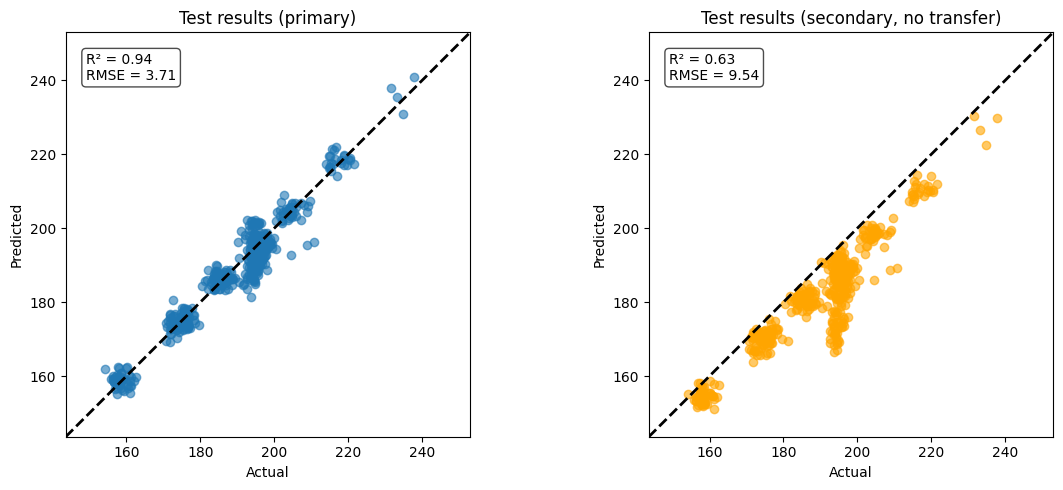

In [67]:
from helperfunctions.plot_functions import plot_cv_vs_test
# Test original model on primary instrument test data
x_primary_test_raw = np.array(data_pd[(data_pd["instrument"]==primary_name) & (data_pd["type"]=="test")].iloc[:,6:])
y_primary_test = np.array(data_pd[(data_pd["instrument"]==primary_name) & (data_pd["type"]=="test")].loc[:,y_name])

y_pred_primary = pls.predict(x_primary_test_raw).flatten()
y_pred_secondary_notransfer = pls.predict(x_secondary_test_raw).flatten()

plot_cv_vs_test(y_primary_test, y_pred_primary, y_secondary_test, y_pred_secondary_notransfer, ["Test results (primary)", "Test results (secondary, no transfer)"])

## Transfer with Direct Standardization (DS)

DS finds a linear transformation matrix F that relates the two instruments:
X_secondary = X_primary * F + residuals

The transformation is found by: F = (X_primary^T * X_primary)^(-1) * X_primary^T * X_secondary

Then we can transform the regression vector: B_ds = F * B

In [68]:
x_primary = x_primary_raw.copy()
x_secondary = x_secondary_raw.copy()

In [69]:
F, a = caltransfer.ds_pc_transfer_fit(x_primary, x_secondary, max_ncp = 5)
B_ds = F.dot(B.T)
beta_s = a.dot(B_ds) + beta

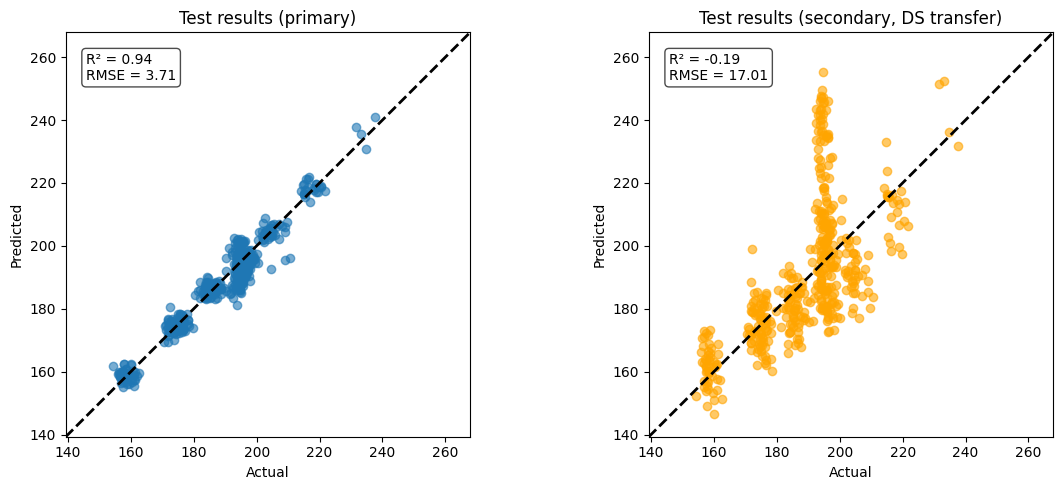

In [70]:
y_pred_ds = pls.predict(x_secondary_test_raw.dot(F)+a)
plot_cv_vs_test(y_primary_test, y_pred_primary, y_secondary_test, y_pred_ds, ["Test results (primary)", "Test results (secondary, DS transfer)"])

## Transfer with Piecewise Direct Standardization (PDS)

PDS is an improvement over DS that uses local windows around each wavelength. Instead of a global transformation, it builds local transformations using neighboring wavelengths. This can handle non-linear relationships better than DS.

The window size (ww) is a critical parameter - larger windows are more stable but less flexible, smaller windows are more flexible but can overfit.

In [71]:
F_pds,b = caltransfer.pds_pls_transfer_fit(x_primary, x_secondary, max_ncp = 1, ww = 3)
B_pds = F_pds.dot(B.T)

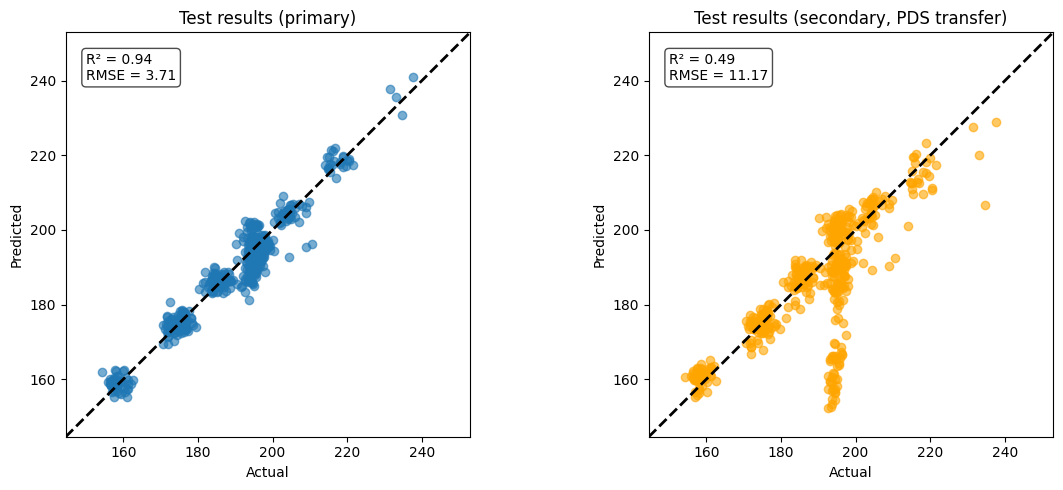

In [72]:
y_pred_pds = pls.predict(x_secondary_test_raw.dot(F_pds)+b)
plot_cv_vs_test(y_primary_test, y_pred_primary, y_secondary_test, y_pred_pds, ["Test results (primary)", "Test results (secondary, PDS transfer)"])

## Trying wth a different dataset

In [73]:
import scipy.io

filepath = "data/plant_point_to_camera.mat"
mat = scipy.io.loadmat(filepath)

In [74]:
mat["b1"]["x"][0,0].shape

(543, 712)

In [75]:
import kennard_stone as ks

X_cal_ks_primary, X_test_ks_primary, y_cal_ks_primary, y_test_ks_primary = ks.train_test_split(mat["b1"]["x"][0,0], mat["b1"]["y"][0,0], test_size = 0.2, random_state=1)
def get_indices(X_original, X_subset):
    return [np.where(np.all(np.isclose(X_original, x), axis=1))[0][0] for x in X_subset]

train_idx_primary = get_indices(mat["b1"]["x"][0,0], X_cal_ks_primary)

X_cal_ks_secondary, X_test_ks_secondary, y_cal_ks_secondary, y_test_ks_secondary = ks.train_test_split(mat["b2"]["x"][0,0], mat["b2"]["y"][0,0], test_size = 0.2, random_state=1)
train_idx_secondary = get_indices(mat["b2"]["x"][0,0], X_cal_ks_secondary)

overlapping_train_idx = set(train_idx_primary) & set(train_idx_secondary)

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/kennard_stone/_core/_core.py:313: IgnoredArgumentWarning: `random_state` is unnecessary since it is uniquely determined in this algorithm.
  warnings.warn(
/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-08-29 15:44:48,922 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
2025-08-29 15:44:48,932 - kennard_stone.utils._pairwise:109[INFO] - Calculating pairwise distances using scikit-learn.

/home/liza/miniforge3/envs/hyperspectral311/lib/python3.11/site-packages/sk

100.0% completed
Suggested number of components: 20


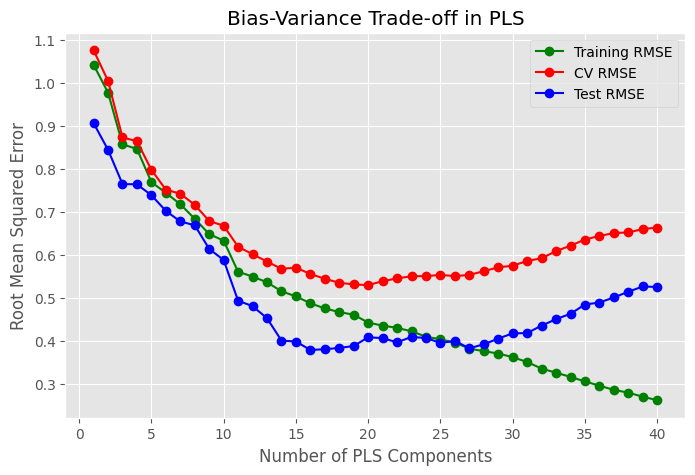

In [76]:
from helperfunctions.optimize import optimise_pls_cv_test
opt_n_comp = optimise_pls_cv_test(X_cal_ks_primary, y_cal_ks_primary, X_test_ks_primary, y_test_ks_primary, n_comp=40)

/tmp/ipykernel_26373/2838967086.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc = 0)


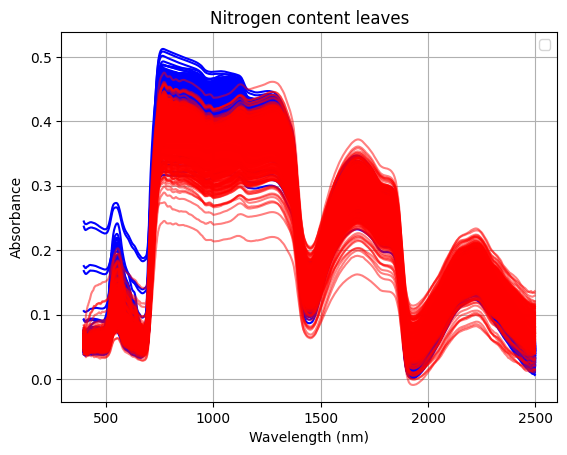

In [77]:
plt.plot(mat["b1"]["w"][0,0].T,mat["b1"]["x"][0,0].T, c = "blue")
plt.plot(mat["b2"]["w"][0,0].T,mat["b2"]["x"][0,0].T, c = "red", alpha = 0.5)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Absorbance")
plt.title("Nitrogen content leaves")
plt.legend(loc = 0)
plt.grid()
plt.show()

In [78]:
import random

n_transfer = 15
transfer_samples = random.sample(list(overlapping_train_idx), n_transfer)


In [79]:
mod_lv = opt_n_comp
x_primary_cal = X_cal_ks_primary.copy()
x_mean = np.mean(x_primary_cal,axis=0)

pls = PLSRegression(n_components = mod_lv,scale=False)
pls.fit(x_primary_cal, y_cal_ks_primary)
T_scores = (x_primary_cal-x_mean).dot(pls.x_rotations_)
pls_ls = LinearRegression()
pls_ls.fit(T_scores,y_cal_ks_primary) # output values need to be 1D always here

# deliver parameters for plsr
R = pls.x_rotations_ #loadings to calculate scores
q = pls_ls.coef_ # Y-regression coefficients
y_mean = pls_ls.intercept_ # Y-intercept
B = pls.coef_ # Final regression vector (X -> Y)
beta = y_mean - (x_mean.dot(B.T)) # Adjusted intercept

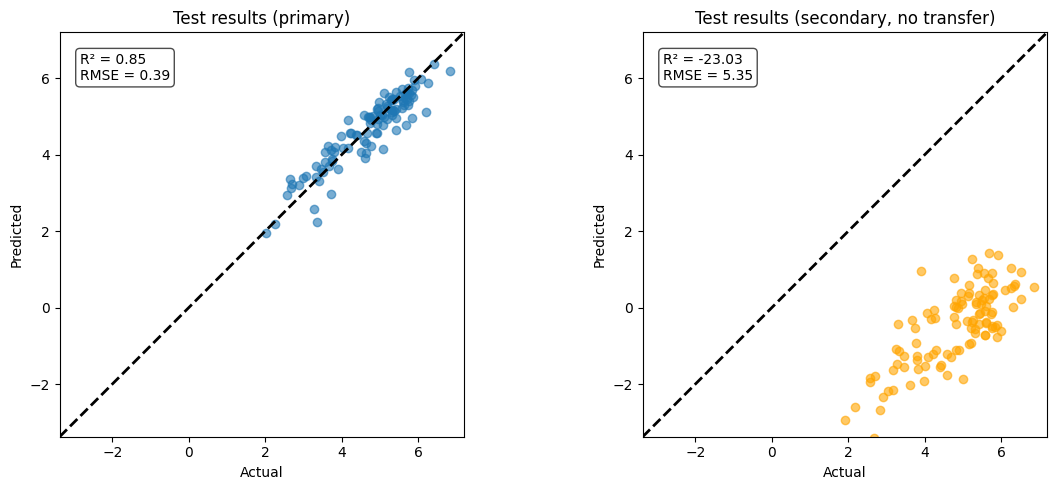

In [80]:
y_pred_primary = pls.predict(X_test_ks_primary).flatten()
y_pred_secondary_notransfer = pls.predict(X_test_ks_secondary).flatten()

plot_cv_vs_test(y_test_ks_primary, y_pred_primary, y_test_ks_secondary, y_pred_secondary_notransfer, ["Test results (primary)", "Test results (secondary, no transfer)"])

In [81]:
x_primary = mat["b1"]["x"][0,0][transfer_samples, :]
x_secondary = mat["b2"]["x"][0,0][transfer_samples, :]

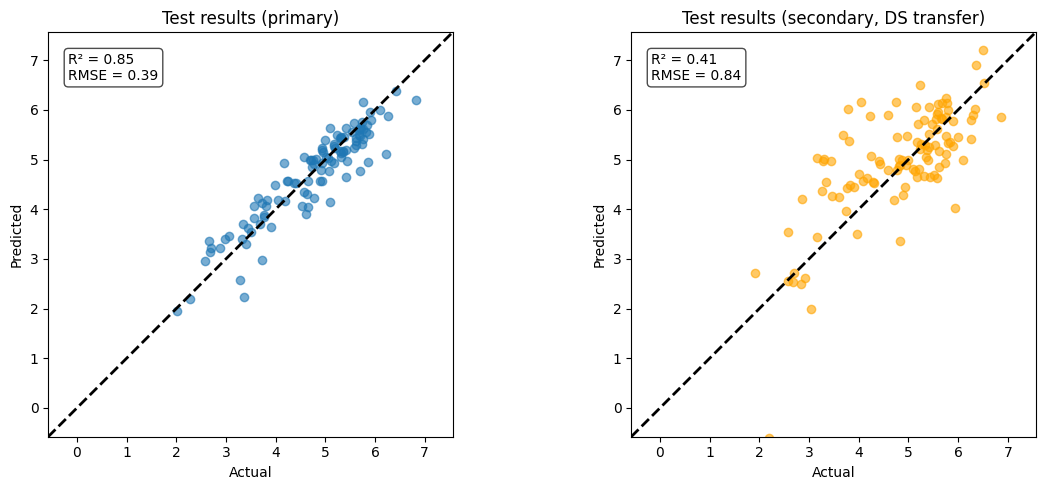

In [82]:
F_ds,b = caltransfer.ds_pc_transfer_fit(x_primary, x_secondary, max_ncp = 8)
B_ds = F_ds.dot(B.T)
y_pred_ds = pls.predict(X_test_ks_secondary.dot(F_ds)+b).flatten()
plot_cv_vs_test(y_test_ks_primary, y_pred_primary, y_test_ks_secondary, y_pred_ds, ["Test results (primary)", "Test results (secondary, DS transfer)"])

In [ ]:
from sklearn.metrics import mean_squared_error

ww_values = [3, 5, 7, 11, 15, 21]
max_ncp_values = [1, 2, 3, 5, 8]
best_score = float('inf')
best_params = None

for ww in ww_values:
    for max_ncp in max_ncp_values:
        F_pds, b = caltransfer.pds_pls_transfer_fit(x_primary, x_secondary, max_ncp=max_ncp, ww=ww)
        y_pred_pds = pls.predict(X_test_ks_secondary.dot(F_pds) + b).flatten()
        score = mean_squared_error(y_test_ks_secondary.flatten(), y_pred_pds)
        if score < best_score:
            best_score = score
            best_params = (ww, max_ncp)

print(f"Best window size (ww): {best_params[0]}, Best max_ncp: {best_params[1]}, MSE: {best_score:.4f}")

Best window size (ww): 3, Best max_ncp: 1, MSE: 1.1237


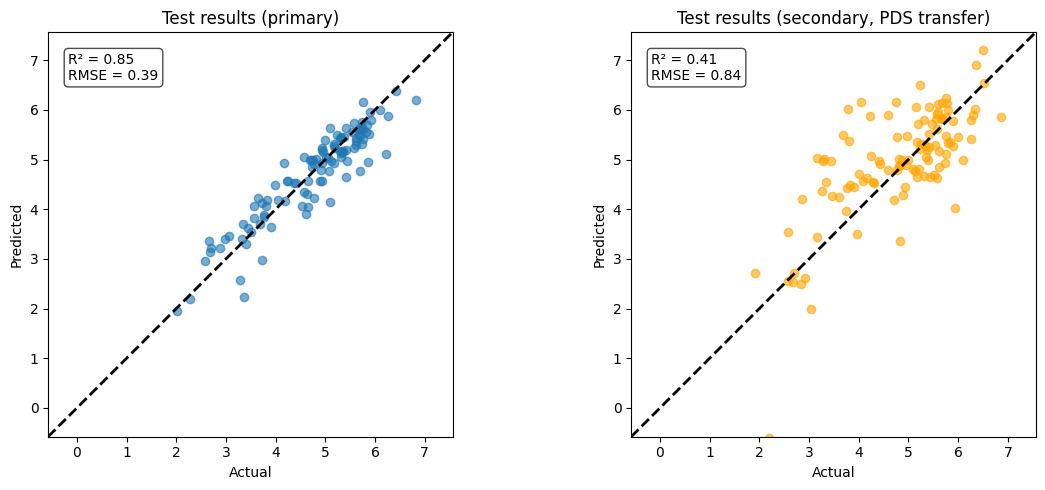

In [85]:
F_pds, b = caltransfer.pds_pls_transfer_fit(x_primary, x_secondary, max_ncp=best_params[1], ww=best_params[0])
y_pred_pds = pls.predict(X_test_ks_secondary.dot(F_pds) + b).flatten()
plot_cv_vs_test(y_test_ks_primary, y_pred_primary, y_test_ks_secondary, y_pred_ds, ["Test results (primary)", "Test results (secondary, PDS transfer)"])

## Summary

- Direct use of a model on a different instrument often fails.
- DS and PDS are practical methods for transferring models across instruments.
- PDS usually performs better when spectral differences are non-linear or local.

In real applications, always validate the transfer with a small set of shared samples.
